In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




In [2]:
df_fake=pd.read_csv('../data/raw/Fake.csv')
df_true=pd.read_csv('../data/raw/True.csv')

### checking null/ duplicates and removing them.

In [3]:

df_fake.head()
df_fake.isna().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [4]:
df_fake[df_fake.duplicated(keep=False)]

,title,text,subject,date
9941,HILLARY TWEETS MESSAGE In Defense Of DACA…OOPS...,No time to waste we've got to fight with eve...,politics,"Sep 9, 2017"
9942,HILLARY TWEETS MESSAGE In Defense Of DACA…OOPS...,No time to waste we've got to fight with eve...,politics,"Sep 9, 2017"
11445,FORMER DEMOCRAT WARNS Young Americans: “Rioter...,"Who is silencing political speech, physically...",politics,"Mar 10, 2017"
11446,FORMER DEMOCRAT WARNS Young Americans: “Rioter...,"Who is silencing political speech, physically...",politics,"Mar 10, 2017"
14924,[VIDEO] #BlackLivesMatter Terrorists Storm Dar...,They were probably just looking for a safe sp...,politics,"Nov 16, 2015"
14925,[VIDEO] #BlackLivesMatter Terrorists Storm Dar...,They were probably just looking for a safe sp...,politics,"Nov 16, 2015"


In [5]:
df_fake=df_fake.drop_duplicates(keep='first')
df_fake[df_fake.duplicated(keep=False)]

,title,text,subject,date


In [6]:
df_true.head()


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [7]:
df_true.isna().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [8]:
df_true.duplicated().sum()

np.int64(206)

In [9]:
df_true=df_true.drop_duplicates(keep='first')

In [10]:
df_true.duplicated().sum()

np.int64(0)

### checking columns and merging datasets


In [11]:
print(f'columns in fake data: {df_fake.columns}')
print(f'columns in real data: {df_true.columns}')

columns in fake data: Index(['title', 'text', 'subject', 'date'], dtype='object')
columns in real data: Index(['title', 'text', 'subject', 'date'], dtype='object')


### adding columns as fake and real for respective news~

In [12]:
df_fake['type']='0'
df_true['type']='1'

In [13]:
df=pd.concat([df_fake,df_true],axis=0, ignore_index=True)

In [14]:
df

,title,text,subject,date,type
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0
...,...,...,...,...,...
44684,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",1
44685,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",1
44686,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1
44687,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1


In [15]:
#checking if the data is balanced or imbalanced
print(df['type'].value_counts(normalize=True))

print('\n')

#checking the shape of data

print(df.shape)

type
0    0.525364
1    0.474636
Name: proportion, dtype: float64


(44689, 5)


In [16]:
# adding text length features
df['title_len']=df['title'].str.len()
df['text_len']=df['text'].str.len()
df['word_count']=df['text'].str.split().str.len()


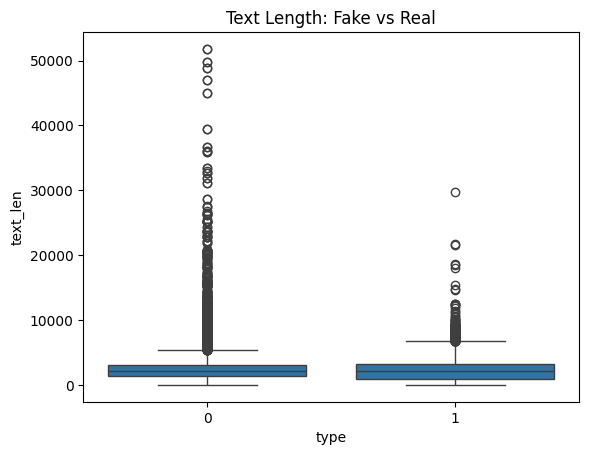

In [17]:
# creating boxplot
sns.boxplot(data=df, x='type',y='text_len')
plt.title('Text Length: Fake vs Real')
plt.show()

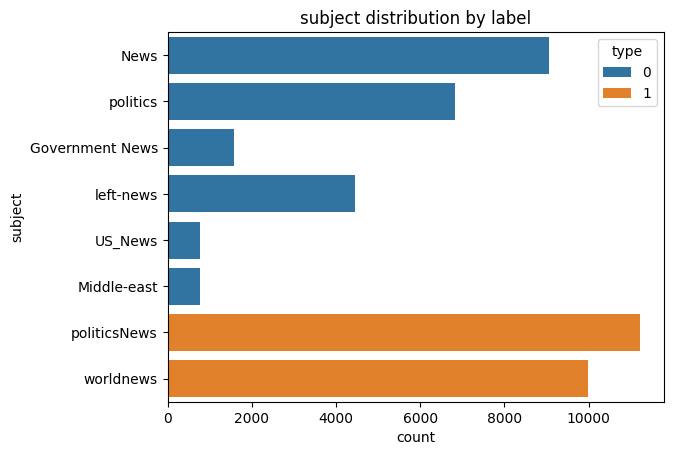

In [18]:
# subject distribution on fake vs real news

sns.countplot(data=df, y='subject',hue='type')
plt.title('subject distribution by label')
plt.show()

In [30]:
import re

def clean_text(text):
    text = str(text)
    text = text.strip()
    text = re.sub(r"\s+", " ", text)   # remove extra spaces/newlines
    return text

In [31]:
df['transformed_text']=df['text'].apply(clean_text)

In [32]:
df['transformed_title']=df['title'].apply(clean_text)

In [33]:
df['transformed_text_title']=df['transformed_text'] + ' ' + df['transformed_title']

In [34]:
processed_df= df[['transformed_text_title','type']]


In [35]:
processed_df.to_csv('../data/processed/final_df.csv')